# Subscription Service – OLS Regression for TotalCharges Prediction

This notebook builds and evaluates two OLS regression models to predict **TotalCharges** of subscription service customers, using 5-Fold Cross-Validation with the R-squared metric.

**Objective**

- Predict TotalCharges using OLS regression with 5-Fold Cross-Validation (R² metric). Two competing models were evaluated.
- Predict the expected total charges of a 25 month of account age and average viewing duration is 100/minutes

### Setup & Import Libraries

Three main libraries are imported according to their roles:
- **Data**: `pandas`, `numpy`
- **Visualization**: `matplotlib`, `seaborn`
- **Modeling & Evaluation**: `statsmodels` (OLS), `sklearn` (cross-validation wrapper)

The combination of statsmodels + sklearn is necessary because statsmodels does not natively support the `cross_val_score` API.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score, KFold

### Helper Functions & Wrapper Classes

**`print_coef_std_err(results)`** — Extracts the coefficients and standard errors from statsmodels results into a single DataFrame; this simplifies interpretation and comparison between models.

**`StatsmodelsRegressor`** — A wrapper class that encapsulates OLS statsmodels into sklearn's `BaseEstimator` interface, allowing them to be used directly by `cross_val_score`. The `fit()` method accepts an entire DataFrame (not an array), as statsmodels formulas work with column names.

**`kfold_split()`** — A manual fold splitter for visually inspecting the data composition of each fold; the result is not used directly by `cross_val_score`, but is useful for verification. This function is created solely for manual verification and education — ensuring the fold distribution looks reasonable before running a full experiment.

In [2]:
def print_coef_std_err(results):
    """
    Combine estimated coefficients and standard error into one DataFrame.
    :param results: statsmodels RegressionResultsWrapper
    :return: pandas DataFrame with columns ['coef', 'std err']
    """
    coef = results.params
    std_err = results.bse
    return pd.DataFrame(
        data=np.transpose([coef, std_err]),
        index=coef.index,
        columns=['coef', 'std err']
    )


class StatsmodelsRegressor(BaseEstimator, RegressorMixin):
    """sklearn-style wrapper for statsmodels OLS."""

    def __init__(self, sm_class, sm_formula):
        self.sm_class = sm_class
        self.sm_formula = sm_formula
        self.model = None
        self.result = None

    def fit(self, data, dummy):
        self.model = self.sm_class(self.sm_formula, data)
        self.result = self.model.fit(disp=0)

    def predict(self, X):
        return self.result.predict(X)


def kfold_split(data, n_fold):
    """
    Split data into K folds, return (fold_train, fold_test) dicts.
    :param data: pandas DataFrame
    :param n_fold: number of folds (int)
    """
    kfold = KFold(n_splits=n_fold, shuffle=True, random_state=123)
    fold_train, fold_test = {}, {}
    for i, (train, test) in enumerate(kfold.split(data)):
        print(f'fold {i+1}, train: {len(train)} rows, test: {len(test)} rows')
        fold_train[i] = data.iloc[train].copy()
        fold_test[i]  = data.iloc[test].copy()
    return fold_train, fold_test

### Load Data


In [3]:
sub = pd.read_csv('Subscription_Service_Churn_Dataset.csv')
sub.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,42,11.321950,475.521914,Basic,Electronic check,Yes,Movies,Yes,Tablet,0.386852,...,25,Comedy,3.489465,7,Female,15,No,No,LOHRYYC9E8,0
1,95,12.810915,1217.036887,Standard,Electronic check,Yes,TV Shows,No,Mobile,37.123000,...,21,Comedy,2.251860,3,Male,8,No,NaN,RIH7RFEZCS,0
2,6,NaN,91.583304,Standard,Credit card,Yes,TV Shows,No,Tablet,30.716944,...,29,Fantasy,NaN,4,Male,14,No,Yes,JB5J8X2UY1,1
3,54,17.917819,967.562224,Basic,NaN,Yes,Movies,No,Mobile,2.495373,...,45,Drama,1.275004,3,Male,12,No,NaN,Z4GZJIB90P,0
4,27,NaN,339.057244,Basic,Mailed check,No,TV Shows,No,Mobile,39.936910,...,44,Comedy,3.236230,4,Female,18,No,NaN,B3BDJTW0L9,0


### Check Missing Values

In [4]:
sub.isnull().sum()

AccountAge                    0
MonthlyCharges              204
TotalCharges                186
SubscriptionType             50
PaymentMethod               223
PaperlessBilling              0
ContentType                   0
MultiDeviceAccess             0
DeviceRegistered             76
ViewingHoursPerWeek           0
AverageViewingDuration        0
ContentDownloadsPerMonth      0
GenrePreference             110
UserRating                  261
SupportTicketsPerMonth        0
Gender                       40
WatchlistSize                 0
ParentalControl               0
SubtitlesEnabled            800
CustomerID                    0
Churn                         0
dtype: int64


- Before imputation, we checked the number of missing values ​​per column. 
- Some columns had significant missing values

### Missing Values ​​Imputation

Imputation strategies differ based on column type:

- **Numeric columns** (`MonthlyCharges`, `TotalCharges`, `UserRating`): padded with the **median**. The median is more robust to skewed distributions than the mode, so it doesn't skew the imputed values ​​toward outliers.
- **Categorical columns**: added with the **mode** — the most frequently occurring value — because there is no concept of a "middle" in nominal data.

In [5]:
# Numeric column: fill with MEDIAN (more robust against outliers than mode)

sub['MonthlyCharges'] = sub['MonthlyCharges'].fillna(sub['MonthlyCharges'].median())
sub['TotalCharges']   = sub['TotalCharges'].fillna(sub['TotalCharges'].median())
sub['UserRating']     = sub['UserRating'].fillna(sub['UserRating'].median())

# Categorical columns: fill with MODUS
for col in ['SubscriptionType', 'PaymentMethod', 'DeviceRegistered',
            'GenrePreference', 'Gender', 'SubtitlesEnabled']:
    sub[col] = sub[col].fillna(sub[col].mode()[0])

### Exploratory Data Analysis (EDA)

**Correlation Matrix**

Correlations between numeric variables are calculated. This helps identify which variables have the potential to be good predictors for the regression model.

In [6]:
sub[['AccountAge','TotalCharges','ViewingHoursPerWeek','AverageViewingDuration',
     'ContentDownloadsPerMonth','UserRating','SupportTicketsPerMonth',
     'WatchlistSize','Churn']].corr()

,AccountAge,TotalCharges,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,UserRating,SupportTicketsPerMonth,WatchlistSize,Churn
AccountAge,1.000000,0.745770,-0.038964,-0.042866,-0.026435,0.002998,0.009497,-0.030794,-0.218671
TotalCharges,0.745770,1.000000,-0.006231,-0.067224,-0.032704,0.039838,-0.009094,-0.014993,-0.135844
ViewingHoursPerWeek,-0.038964,-0.006231,1.000000,0.005447,-0.004270,-0.001617,-0.000521,-0.011861,-0.126287
AverageViewingDuration,-0.042866,-0.067224,0.005447,1.000000,0.043975,0.044849,0.025656,0.049465,-0.129019
ContentDownloadsPerMonth,-0.026435,-0.032704,-0.004270,0.043975,1.000000,0.054620,-0.008234,-0.028011,-0.115284
UserRating,0.002998,0.039838,-0.001617,0.044849,0.054620,1.000000,-0.011851,-0.008689,0.001468
SupportTicketsPerMonth,0.009497,-0.009094,-0.000521,0.025656,-0.008234,-0.011851,1.000000,-0.012001,0.093930
WatchlistSize,-0.030794,-0.014993,-0.011861,0.049465,-0.028011,-0.008689,-0.012001,1.000000,0.033328
Churn,-0.218671,-0.135844,-0.126287,-0.129019,-0.115284,0.001468,0.093930,0.033328,1.000000


**Groupby Analysis**

The average `TotalCharges` is calculated per segment: `SubscriptionType`, `PaymentMethod`, and `Churn` status. The goal is to determine if there are meaningful differences in cost patterns between customer groups.

In [7]:
print('=== Mean TotalCharges by SubscriptionType ===')
print(sub.groupby('SubscriptionType')['TotalCharges'].mean())
print()
print('=== Mean TotalCharges by PaymentMethod ===')
print(sub.groupby('PaymentMethod')['TotalCharges'].mean())
print()
print('=== Mean TotalCharges by Churn status ===')
print(sub.groupby('Churn')['TotalCharges'].mean())

=== Mean TotalCharges by SubscriptionType ===
SubscriptionType
Basic       684.067922
Premium     690.585274
Standard    711.264828
Name: TotalCharges, dtype: float64

=== Mean TotalCharges by PaymentMethod ===
PaymentMethod
Bank transfer       686.248272
Credit card         699.847656
Electronic check    687.947771
Mailed check        708.244935
Name: TotalCharges, dtype: float64

=== Mean TotalCharges by Churn status ===
Churn
0    723.623698
1    559.182549
Name: TotalCharges, dtype: float64


**Pairplot by MultiDeviceAccess**

The distribution and relationships between numeric variables are visualized, separated by multi-device access.

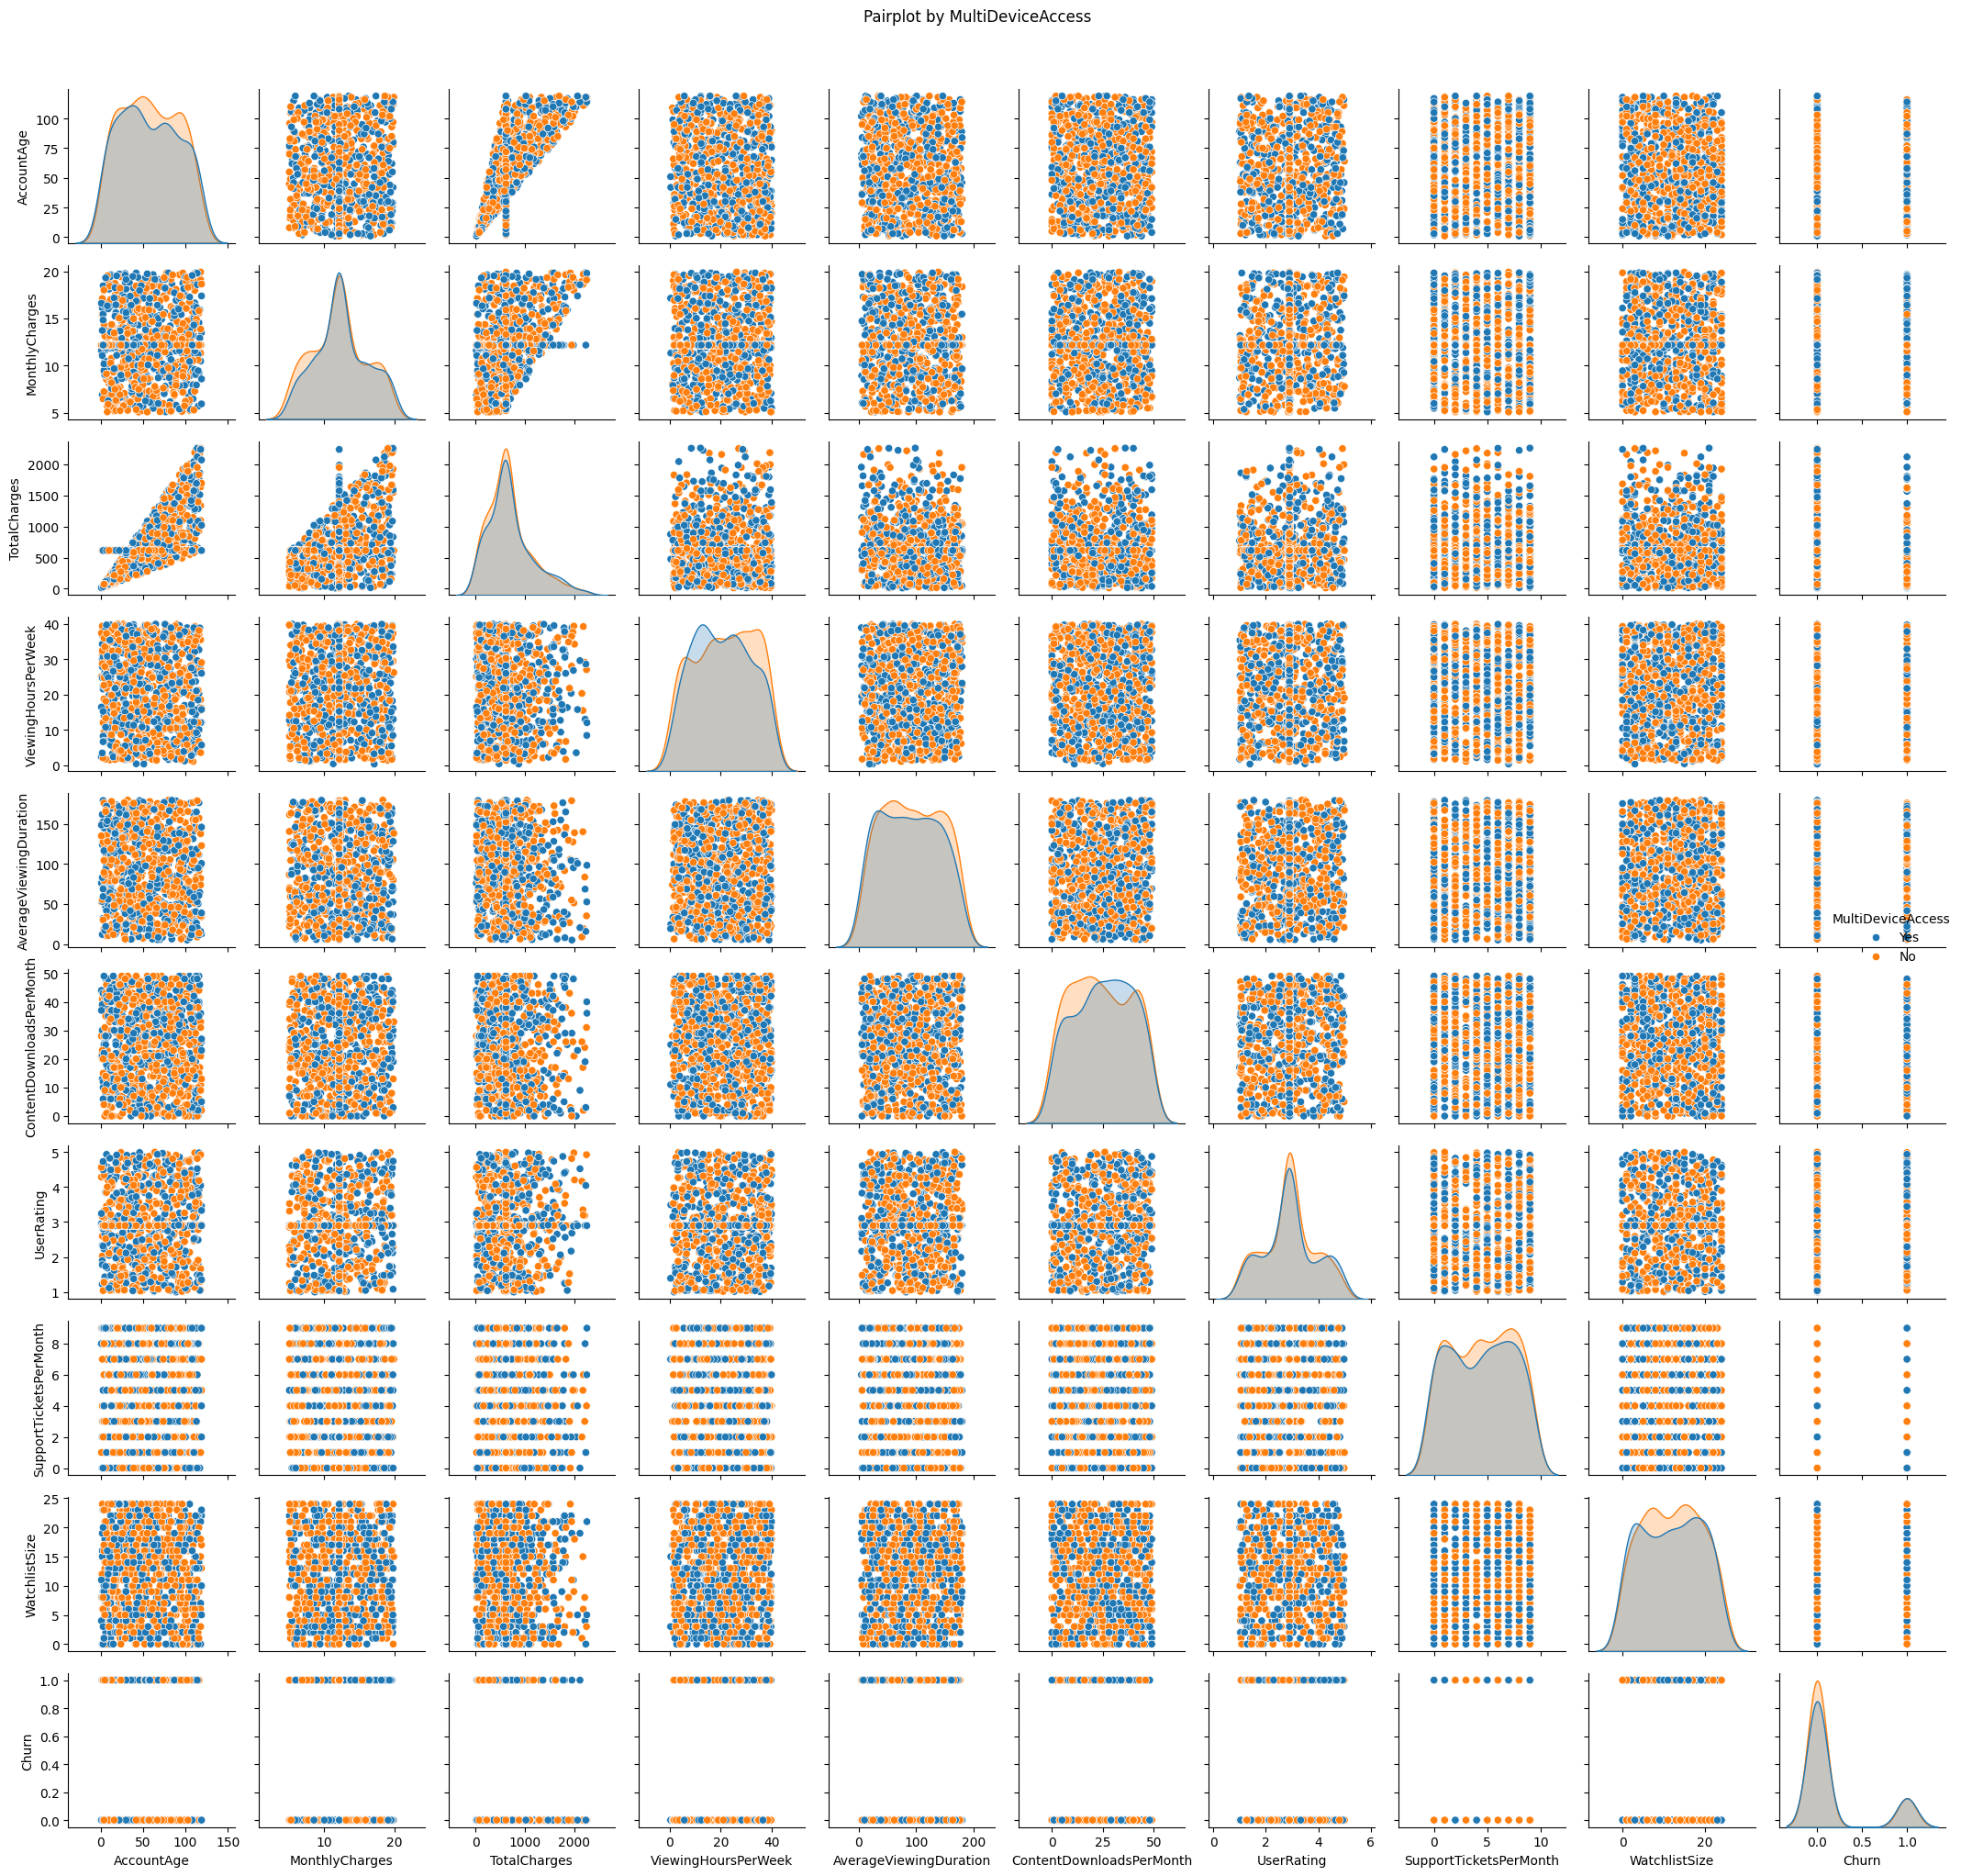

In [8]:
sns.pairplot(data=sub, hue='MultiDeviceAccess', height=2)
plt.suptitle('Pairplot by MultiDeviceAccess', y=1.02)
plt.tight_layout()
plt.show()

**Pairplot by Churn Status**

The same pairplot is repeated with the `Churn` hue (0 = no churning, 1 = churning). This shows whether there is a visual separation between churn classes on a particular variable.

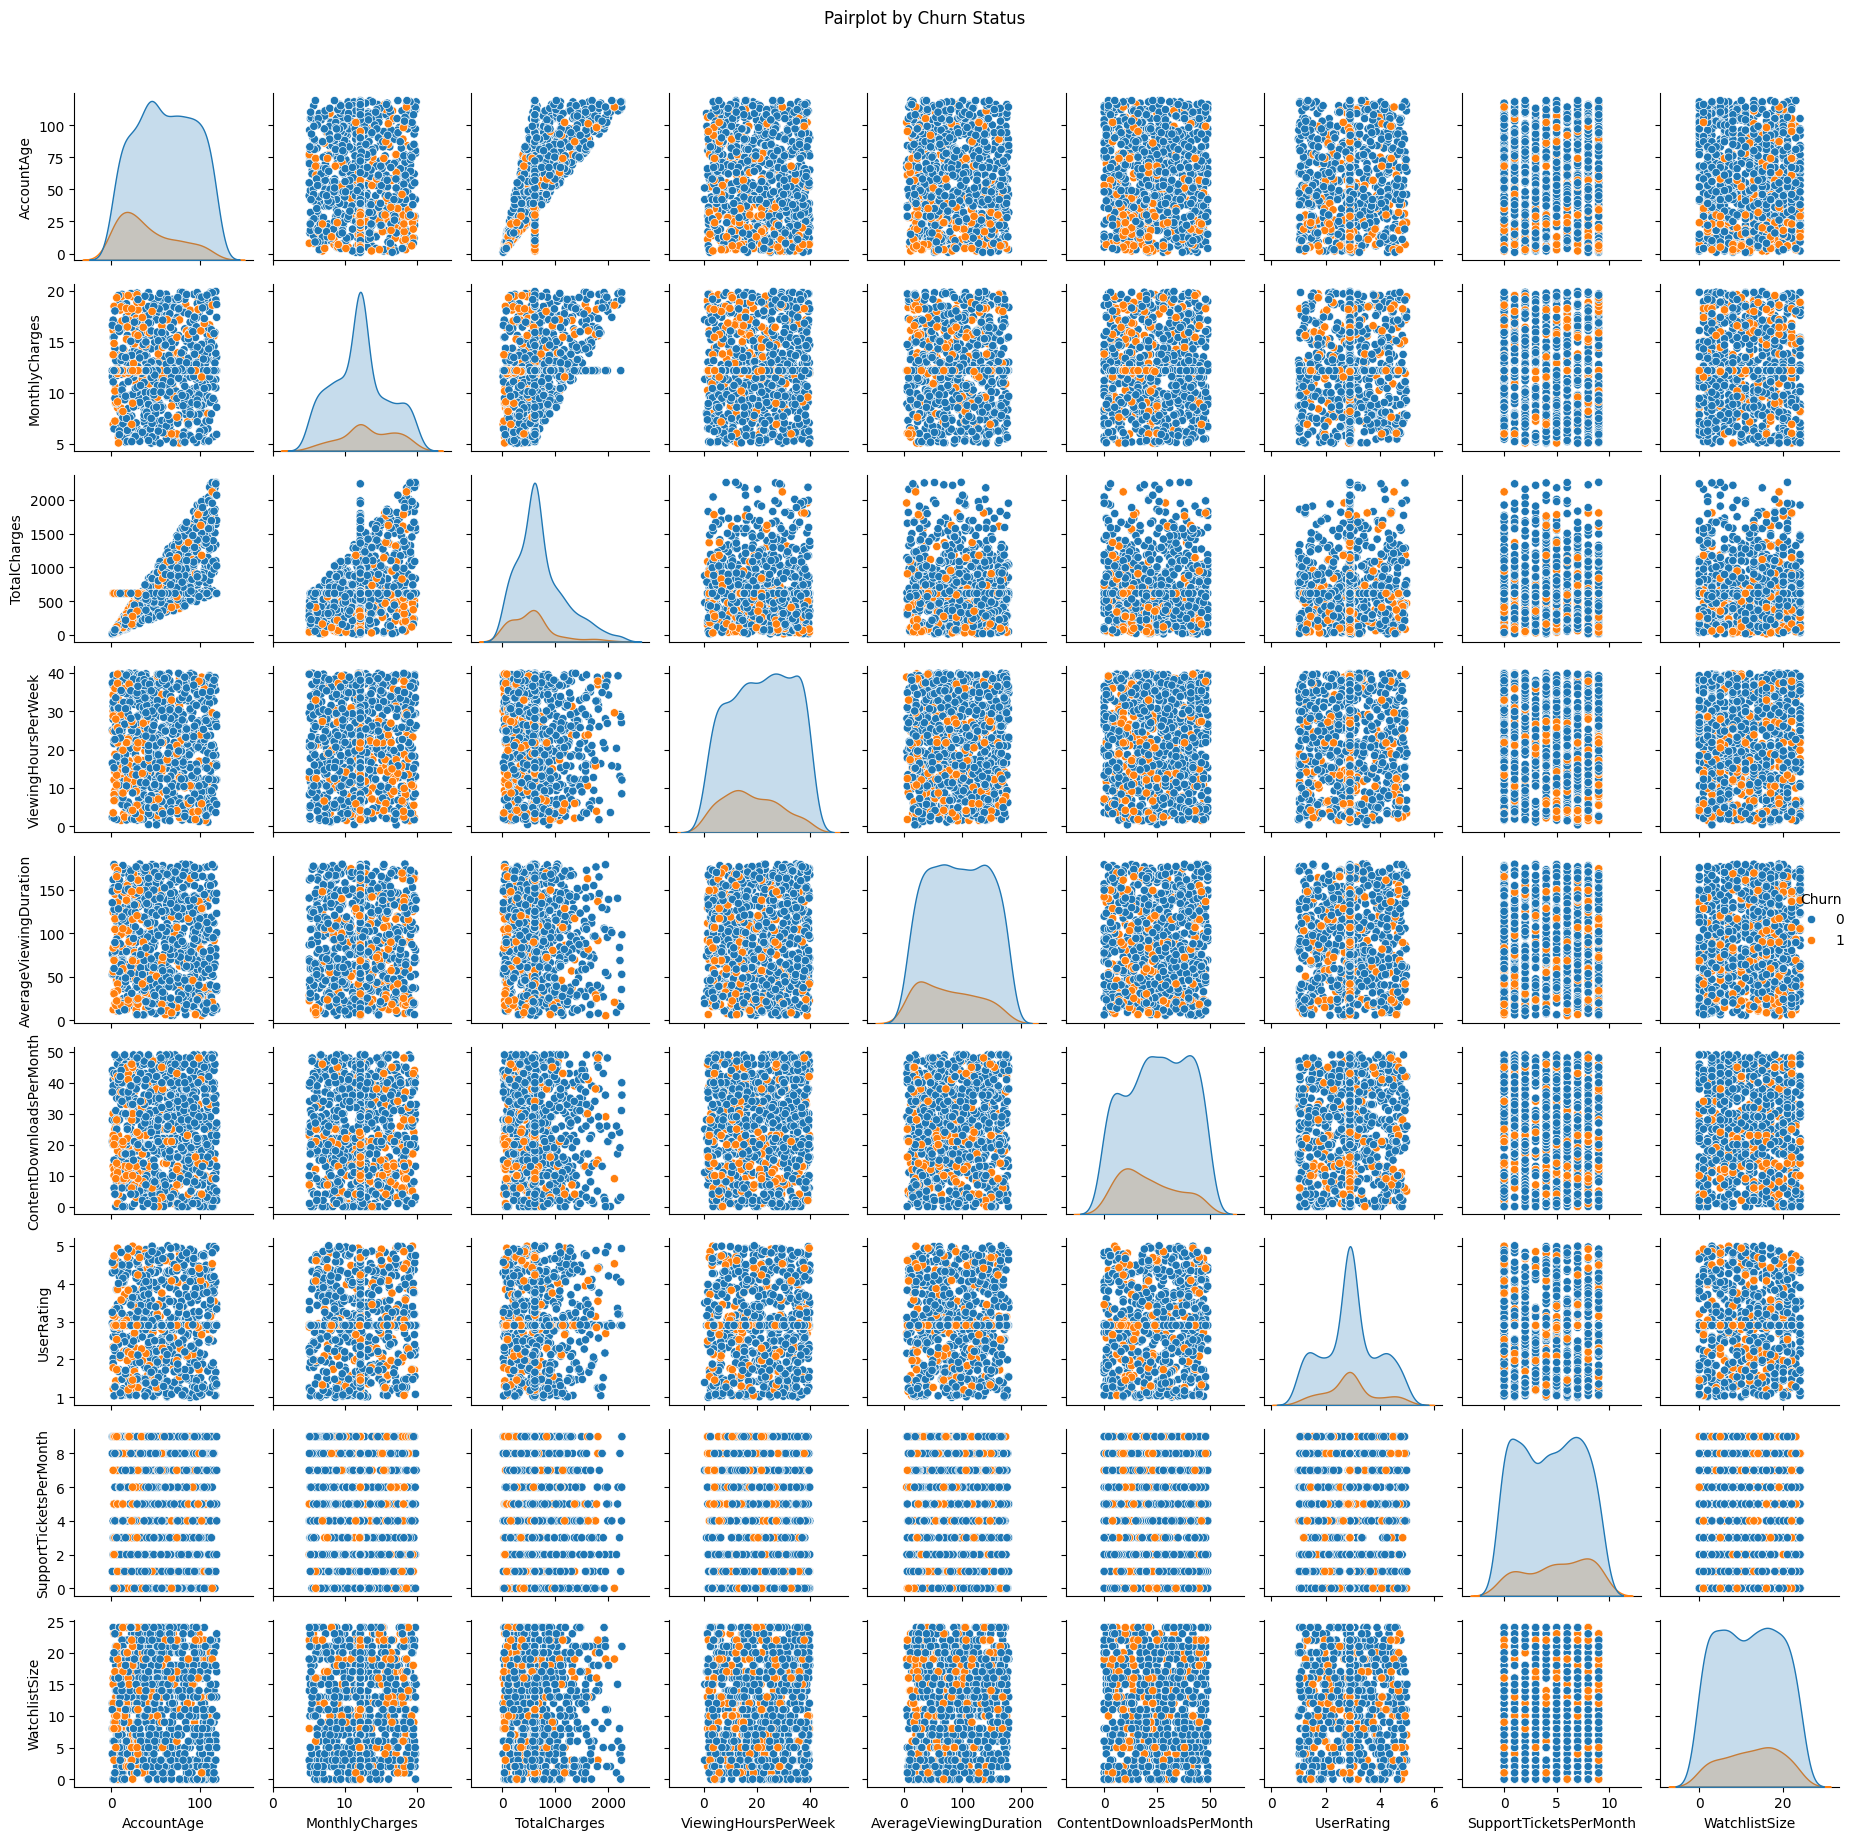

In [9]:
sns.pairplot(data=sub, hue='Churn', height=2)
plt.suptitle('Pairplot by Churn Status', y=1.02)
plt.tight_layout()
plt.show()

- From the pairplot by Churn, there is no clear visual separation between the churned and non-churned groups on most of the variables, indicating that the churn pattern cannot be explained by a single variable."

### Definisi Model

Two OLS models are defined as `StatsmodelsRegressor` objects:

- **Model 1**: `TotalCharges ~ AverageViewingDuration + AccountAge`
- **Model 2**: `TotalCharges ~ UserRating + AccountAge`

The target variable is `TotalCharges` — this is a **regression** task, not a classification one. Both models test whether user viewing behavior or ratings, combined with account age, can explain variation in total subscriber costs.

In [10]:
# Model 1: TotalCharges ~ AverageViewingDuration + AccountAge
ols_view_age   = StatsmodelsRegressor(smf.ols, 'TotalCharges ~ AverageViewingDuration + AccountAge')

# Model 2: TotalCharges ~ UserRating + AccountAge
ols_rating_age = StatsmodelsRegressor(smf.ols, 'TotalCharges ~ UserRating + AccountAge')

### K-Fold Cross-Validation



**Manual fold inspection** using `kfold_split()`. With 5 folds and 963 rows, each test fold contains ~193 rows and the train fold contains ~770 rows.

In [11]:
fold_train, fold_test = kfold_split(data=sub, n_fold=5)

fold 1, train: 770 rows, test: 193 rows
fold 2, train: 770 rows, test: 193 rows
fold 3, train: 770 rows, test: 193 rows
fold 4, train: 771 rows, test: 192 rows
fold 5, train: 771 rows, test: 192 rows


Check the first 5 rows of **train** data in the first fold.

In [12]:
fold_train[0].head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,42,11.321950,475.521914,Basic,Electronic check,Yes,Movies,Yes,Tablet,0.386852,...,25,Comedy,3.489465,7,Female,15,No,No,LOHRYYC9E8,0
1,95,12.810915,1217.036887,Standard,Electronic check,Yes,TV Shows,No,Mobile,37.123000,...,21,Comedy,2.251860,3,Male,8,No,Yes,RIH7RFEZCS,0
2,6,12.169888,91.583304,Standard,Credit card,Yes,TV Shows,No,Tablet,30.716944,...,29,Fantasy,2.898328,4,Male,14,No,Yes,JB5J8X2UY1,1
3,54,17.917819,967.562224,Basic,Credit card,Yes,Movies,No,Mobile,2.495373,...,45,Drama,1.275004,3,Male,12,No,Yes,Z4GZJIB90P,0
6,69,17.145910,1183.067820,Basic,Credit card,No,Movies,Yes,Mobile,19.008900,...,35,Sci-Fi,4.933494,6,Female,5,No,Yes,8VFNZ1M1I9,1


Check the first 5 rows of **test** data in the first fold.

In [13]:
fold_test[0].head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
4,27,12.169888,339.057244,Basic,Mailed check,No,TV Shows,No,Mobile,39.936910,...,44,Comedy,3.236230,4,Female,18,No,Yes,B3BDJTW0L9,0
5,71,12.169888,818.287054,Premium,Credit card,No,Movies,Yes,Computer,7.310172,...,30,Comedy,2.779614,6,Female,16,Yes,Yes,5E4TQK5OVX,0
7,76,17.461875,1327.102526,Premium,Electronic check,No,Movies,Yes,Mobile,24.429413,...,32,Fantasy,2.154737,9,Female,11,Yes,Yes,THKWUHOGUL,0
28,77,7.780374,599.088827,Basic,Credit card,Yes,TV Shows,Yes,Computer,23.812614,...,28,Action,4.792038,4,Female,0,Yes,Yes,318N9SO05V,1
31,103,10.726529,1104.832494,Standard,Bank transfer,Yes,TV Shows,Yes,TV,20.755264,...,15,Drama,2.087613,9,Male,11,No,Yes,4TXBLWD375,0


- A `KFold` object is created with `random_state=123` to ensure reproducible splitting results. 
- This object will be used by `cross_val_score` in the next two cells.

In [14]:
kfold = KFold(n_splits=5, shuffle=True, random_state=123)

**Regression Model 1 using AverageViewingDuration and AccountAge Variable**

- `cross_val_score` use estimator `ols_view_age`
- The R² results for each fold are saved to a DataFrame complete with fold labels and model names.

In [15]:
# Model 1 -  ols_view_age
scores_ols_view_age = cross_val_score(
    estimator=ols_view_age,
    X=sub,
    y=sub['TotalCharges'],
    cv=kfold,
    scoring='r2'
)
scores_ols_view_age = pd.DataFrame(data=scores_ols_view_age, columns=['test_rsquared'])
scores_ols_view_age['folds'] = [f'Fold {i+1}' for i in range(5)]
scores_ols_view_age['model'] = 'AverageViewingDuration + AccountAge'
scores_ols_view_age

,test_rsquared,folds,model
0,0.547991,Fold 1,AverageViewingDuration + AccountAge
1,0.505844,Fold 2,AverageViewingDuration + AccountAge
2,0.539075,Fold 3,AverageViewingDuration + AccountAge
3,0.623513,Fold 4,AverageViewingDuration + AccountAge
4,0.517795,Fold 5,AverageViewingDuration + AccountAge


**Regression Model 2 using UserRating and AccountAge Variable**

- `cross_val_score` use estimator `ols_rating_age`
- The R² results for each fold are saved to a DataFrame complete with fold labels and model names.

In [16]:
# Model 2 -  ols_rating_age

scores_ols_rating_age = cross_val_score(
    estimator=ols_rating_age,
    X=sub,
    y=sub['TotalCharges'],
    cv=kfold,
    scoring='r2'
)
scores_ols_rating_age = pd.DataFrame(data=scores_ols_rating_age, columns=['test_rsquared'])
scores_ols_rating_age['folds'] = [f'Fold {i+1}' for i in range(5)]
scores_ols_rating_age['model'] = 'UserRating + AccountAge'
scores_ols_rating_age

,test_rsquared,folds,model
0,0.551925,Fold 1,UserRating + AccountAge
1,0.509096,Fold 2,UserRating + AccountAge
2,0.540794,Fold 3,UserRating + AccountAge
3,0.620808,Fold 4,UserRating + AccountAge
4,0.515742,Fold 5,UserRating + AccountAge


**Model Comparison Summary**

The two DataFrames were combined, and the mean and standard deviation of the R² were calculated per model. The model with the highest mean R² is listed first.

In [17]:
# Summary of comparison of mean R² of both models

summary = pd.concat([scores_ols_view_age, scores_ols_rating_age], ignore_index=True)
mean_scores = (
    summary.groupby('model')['test_rsquared']
    .agg(['mean','std'])
    .rename(columns={'mean':'mean_r2','std':'std_r2'})
    .sort_values('mean_r2', ascending=False)
    .reset_index()
)
print('=== Cross-Validation R² Summary (5-Fold) ===')
mean_scores

=== Cross-Validation R² Summary (5-Fold) ===


,model,mean_r2,std_r2
0,UserRating + AccountAge,0.547673,0.044502
1,AverageViewingDuration + AccountAge,0.546844,0.046002


**R² per Fold Visualization**

Bar charts are plotted side by side for both models. The dashed red line shows the average R² across folds. This visualization makes it easy to compare not only average performance but also consistency (variance) between folds.

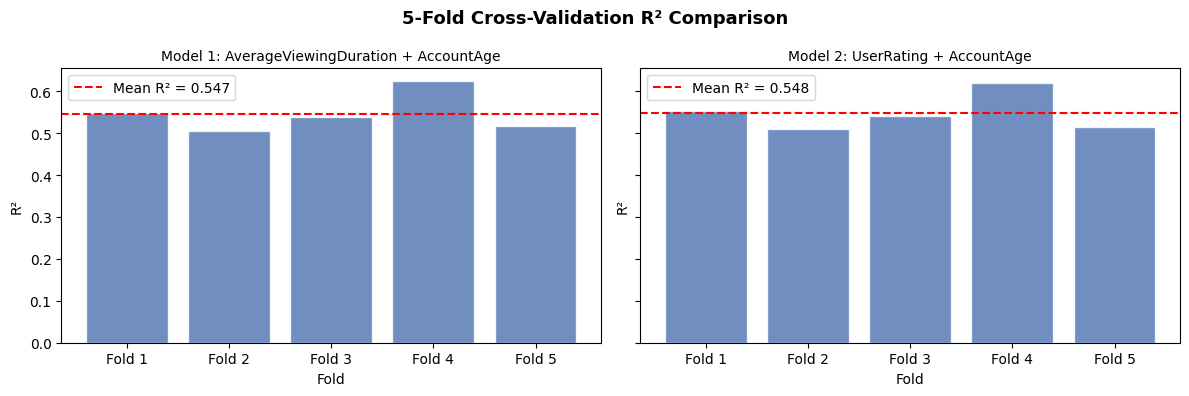

In [18]:
# Visualization of R² per fold for both models

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
pairs = [
    (scores_ols_view_age,   'Model 1: AverageViewingDuration + AccountAge'),
    (scores_ols_rating_age, 'Model 2: UserRating + AccountAge'),
]
for ax, (df_s, title) in zip(axes, pairs):
    ax.bar(df_s['folds'], df_s['test_rsquared'], color='#4C72B0', alpha=0.8, edgecolor='white')
    mean_val = df_s['test_rsquared'].mean()
    ax.axhline(mean_val, color='red', linestyle='--', label=f'Mean R² = {mean_val:.3f}')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Fold')
    ax.set_ylabel('R²')
    ax.legend()
plt.suptitle('5-Fold Cross-Validation R² Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Print the best model based on the highest mean R², along with its standard deviation as a measure of stability.

In [28]:
best = mean_scores.iloc[0]
print(f'Best model : {best["model"]}')
print(f'Mean R²    : {best["mean_r2"]:.4f}')
print(f'Std  R²    : {best["std_r2"]:.4f}')

Best model : UserRating + AccountAge
Mean R²    : 0.5477
Std  R²    : 0.0445


### Final Model: AverageViewingDuration + AccountAge

`AverageViewingDuration` is centered by subtracting its population mean:

```
c_view = `AverageViewingDuration` - mean(`AverageViewingDuration`)
```

Centering does not change the slope coefficient or R², but makes the intercept more meaningful: the intercept now represents the estimated TotalCharges for customers with average viewing hours and the mean account age.

The model is fit, and the coefficients are displayed via print_coef_std_err().

In [20]:
# Centering AverageViewingDuration to make intercepts easier to interpret

sub['c_view'] = sub['AverageViewingDuration'] - sub['AverageViewingDuration'].mean()

model   = smf.ols('TotalCharges ~ c_view + AccountAge', sub)
results = model.fit()

results_ins = print_coef_std_err(results)
results_ins

,coef,std err
Intercept,108.925484,19.594016
c_view,-0.325942,0.198324
AccountAge,10.185853,0.294127


- **In-sample R²** — measures how much of the variation in `TotalCharges` the model can explain on the full training data. 
- This value can be compared to the mean cross-validation R² to detect potential overfitting.

In [21]:
# Explain variance of the final model

results.rsquared

np.float64(0.5574188499507451)

$$\text{TotalCharges} = \beta_0 + \beta_1 \times (\text{View Hours} - \overline{\text{View Hours}}) + \beta_2 \times \text{AccountAge}$$

### Individual Prediction

```
TotalCharges = intercept + (w_account_age × account_age) + (w_c_view × c_view)
```

In [ ]:
# Coefficients of the model
intercept       = results_ins['coef']['Intercept']
w_account_age   = results_ins['coef']['AccountAge']
w_c_view        = results_ins['coef']['c_view']

# Input individual data
view        = 100   # average viewing duration
account_age = 25   # account age in months

# Centering
c_view = view - sub['AverageViewingDuration'].mean()

expected_charges = intercept + w_account_age * account_age + w_c_view * c_view

print(f'Input                  : AverageViewingDuration={view}, AccountAge={account_age}')
print(f'Centered view (c_view) : {c_view:.4f}')
print(f'Predicted TotalCharges : {expected_charges:.2f}')

Input                  : AverageViewingDuration=100, AccountAge=25
Centered view (c_view) : 9.2581
Predicted TotalCharges : 360.55


**Insight**

- The two variables that have positive relation to total charges is age and average views variables
    - The expected total charges of people who don't watch at all (`c_view` = 0) and have just created their account (`AccountAge` = 0) is $108.93

    - Comparing people that have the same account age, people who watch more will have lower total charges by $0.33 for every additional view unit.

    - Comparing people who have the same viewing habits (`c_view`) but differ by 1 year or 1 unit of account age, the person with the older account age has $10.19 higher total charges in average than the younger one.

- The model that have variance use age and AverageView variables, it explained 55% of variance of TotalCharges

- The model predicts a person with an average viewing duration of 100 minutes (`c_view` centered at 9.2581) and an account age of 25 months/units will have expected total charges of $360.55

**Recommendation**

- Customers with longer account age tend to accumulate higher TotalCharges, indicating that retaining customers over time directly increases lifetime value. The subscription service should invest in long-term loyalty programs to extend account age.

- The service can monitor AverageViewingDuration as a behavioral signal: customers with decreasing viewing duration may be at higher risk of disengagement and could be targeted with personalized content recommendations or retention offers.

**Limitation**
The analysis only accounts for viewing behavior and account age variables. The model may explain a limited proportion of TotalCharges variance, suggesting that other important factors — such as subscription type, churn status, payment method, and content preferences — may contribute more meaningfully to TotalCharges and should be explored in future models.